# Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
#Path to project root
PROJECT_ROOT = os.path.abspath("/home/plas_vasileiadis/GraphRAG")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project root added:", PROJECT_ROOT, flush=True)

Project root added: /home/plas_vasileiadis/GraphRAG


# Load and Preprocess Data

In [ ]:
from pipeline.data.load_and_process_dataset import load_to_nodes_HotPotQA, load_to_nodes_MuSiQue, load_to_nodes_2WikiMultiHopQA
nodes, questions, answers = load_to_nodes_HotPotQA(type="easy", num=1)
# nodes, questions, answers = load_to_nodes_MuSiQue(num=1)
# nodes, questions, answers = load_to_nodes_2WikiMultiHopQA(q_type="all", num=1)

Question types:
bridge_comparison: 1

Number Of Nodes: 1



# Configure the LLM, Prompt, and GraphRAG Extractor

## Configure the LLM

In [4]:
from llama_index.llms.llama_cpp import LlamaCPP
from llama_cpp import Llama
llm_path = "/home/plas_vasileiadis/GraphRAG/pipeline/llm/local_models/qwen2_7B_instruct_gguf_Q8/qwen2-7b-instruct-q8_0.gguf"
embedder_path = "/home/plas_vasileiadis/GraphRAG/pipeline/llm/local_embedings/bge-m3-q8_0.gguf/bge-m3-q8_0.gguf"
llm = LlamaCPP(
    model_path=llm_path,
    temperature=0.0,
    max_new_tokens=4096,
    context_window=20000,
    model_kwargs={
        "n_gpu_layers": 45,
        "n_ctx": 20000,
        "n_threads": 8,
    },
    verbose=False,
)
embedder = Llama(
    model_path=embedder_path,
    embedding=True,
    n_ctx=2048,
    n_gpu_layers=25,
    n_threads=8,
    verbose=False,
)

llama_context: n_ctx_seq (20224) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
llama_context: n_ctx_seq (2048) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


## Entities and Relationships extraction

### GraphRAGExtractor Class

In [ ]:
from pipeline.extraction.extractor import GraphRAGExtractor
from pipeline.extraction.prompts import KG_ENTITY_EXTRACT_TMPL, KG_RELATION_EXTRACT_TMPL                                                                                                                                                                                                                                                                                
from pipeline.extraction.parse_functions import parse_en_fn, parse_rel_fn
#instance of class GraphRAGExtractor
kg_extractor = GraphRAGExtractor(
    llm=llm,
    en_extract_prompt=KG_ENTITY_EXTRACT_TMPL,
    rel_extract_prompt=KG_RELATION_EXTRACT_TMPL,  
    parse_en_fn=parse_en_fn,
    parse_rel_fn=parse_rel_fn,
    max_paths_per_chunk=50,
)

# Extracting the Entities and Relationships

In [6]:
subgraphs = []
for node in nodes:
    triples = kg_extractor([node], show_progress = True)
    subgraphs.append(triples)

Extracting paths from text: 100%|██████████| 1/1 [07:53<00:00, 473.62s/it]


## Entities and Relationships Aggregation

In [ ]:
from pipeline.aggregation.aggregator import GraphAggregation
# unique_entities, unique_edges = aggregate(subgraphs)
aggregator = GraphAggregation()
final_entities, final_edges = aggregator.aggregate(subgraphs)

## Knowledge Graph Creation

In [12]:
from pipeline.graph.graph_store import final_graph_node

g_node = final_graph_node(final_entities, final_edges)

Created unified graph with 235 entities and 181 triples.


# Saving the Knowledge Graph

In [13]:
import json
graph_data = {
    "entities": [{"id": node.id,"name": node.name,"label": node.label,"properties": node.properties,} for node in g_node.metadata["KG_NODES_KEY"]],
    "relations": [{"id": rel.id,"label": rel.label,"source_id": rel.source_id,"target_id": rel.target_id,"properties": rel.properties,} for rel in g_node.metadata["KG_RELATIONS_KEY"]]
}

with open("saved_graph.json", "w") as f:
    json.dump(graph_data, f)

# Loading the saved Knowledge Graph

In [14]:
from llama_index.core.graph_stores.types import EntityNode, Relation
import json
from llama_index.core import PropertyGraphIndex
from pipeline.graph.graph_store import GraphRAGStore

with open("saved_graph.json") as f:
    graph_data = json.load(f)

store = GraphRAGStore(llm=llm, embedder=embedder)

for node_data in graph_data["entities"]:
    node = EntityNode(name=node_data["name"],label=node_data["label"],properties=node_data["properties"])
    store.graph.add_node(node)

for rel_data in graph_data["relations"]:
    rel = Relation(label=rel_data["label"],source_id=rel_data["source_id"],target_id=rel_data["target_id"],properties=rel_data["properties"])
    store.graph.add_relation(rel)

## Creating the Graph Index item

In [15]:
index = PropertyGraphIndex(nodes=[],property_graph_store=store,show_progress=True,llm=llm)

# Querying the Graph


GRAPH STATISTICS
Nodes: 235
Edges: 181
Average degree: 1.54
Isolated nodes: 79 (33.62%)
Connected components: 94
Largest component size: 42
(17.87%)

Top nodes by degree:
  heavy metal — degree 11
  gee — degree 9
  the show — degree 8
  badr hari — degree 8
  erhard — degree 8
  steel cage match — degree 7
  el cobarde ii — degree 7
  hari — degree 7
  statutes — degree 7
  blue demon jr. — degree 6


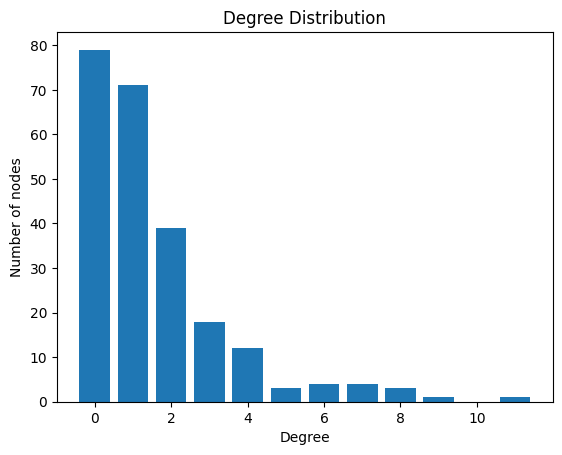

NX Graph created!

Dynamic max_cluster_size set to: 500
Leyden Clusters created!

Clusters organized by level completed!

Hierarchical community detection completed:
  Level 0: 18 communities
Collected element summaries!



/home/plas_vasileiadis/.conda/envs/GraphRAG/lib/python3.10/site-packages/graspologic/partition/leiden.py:607: UserWarning: Leiden partitions do not contain all nodes from the input graph because input graph contained isolate nodes.
  warnings.warn(
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding


Computed leaf summaries!

computed internal summaries!



init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings requ

Builded summary embeddings


init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings requ

GraphRAGStore is complete!



In [16]:
from pipeline.query.query_engine import GraphRAGQueryEngine
from pipeline.query.graph_search import GraphSearch

query_engine = GraphRAGQueryEngine(graph_store=index.property_graph_store, llm=llm, embedder=embedder, final_context_token_limit=15000)
graph_search = GraphSearch(graph_store=index.property_graph_store, llm=llm, embedder=embedder)

In [17]:
from pipeline.query.final_answer import final_synthesis

llms_answers = []
for i, (question, expected_answer) in enumerate(zip(questions, answers)):
    print(f"Question[{i}]: {question}\n")
    graph_answer, graph_summary = graph_search.query(question)
    com_answer, com_summary = query_engine.query(question)
    final_answer = final_synthesis(llm, question, com_answer, com_summary, graph_answer, graph_summary)
    llms_answers.append(final_answer)
    print(f"Llm's response[{i}]: {final_answer}\n")
    print(f"Expected answer[{i}]: {expected_answer}\n")

Question[0]: Who was once considered the best kick boxer in the world, however he has been involved in a number of controversies relating to his "unsportsmanlike conducts" in the sport and crimes of violence outside of the ring.



init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings required but some input tokens were not marked as outputs -> overriding
init: embeddings requ

Llm's response[0]: Badr Hari

Expected answer[0]: Badr Hari



# Evaluation

In [22]:
from pipeline.evaluation.evaluate import Evaluator

evaluator = Evaluator(llm)
results = evaluator.evaluate(llm_answers=llms_answers, gold_answers=answers, queries=questions, k=10,)
for metric, score in results.items():
    print(f"{metric:20s}: {score:.4f}")

exact_match         : 1.0000
f1                  : 1.0000
contains_answer     : 1.0000
hit@10              : 1.0000
llm_score           : 1.0000
